# Détection de faux billets — ONCFM
**Josy Elices-Diez** | Juin 2026

Objectif : classer les billets en vrais / faux à partir de 6 mesures physiques, en comparant 4 algorithmes et en sélectionnant le meilleur sur le critère recall(False).

## 1. Configuration et chargement

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

RANDOM_STATE = 42
FIGURES_DIR = 'figures/'

import os
os.makedirs(FIGURES_DIR, exist_ok=True)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <positron.positron_ipkernel.PositronIPyKernel object at 0x78d27c3d60f0>>
Traceback (most recent call last):
  File "/home/elicesjo/.positron-server/bin/63f0568b148d4d18b7a3194286686d6fb970bed3/extensions/positron-python/python_files/lib/ipykernel/py3/ipykernel/ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "/home/elicesjo/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/threading.py", line 1535, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


In [2]:
df = pd.read_csv('data_raw/billets.csv', sep=';')
print(f'Dimensions : {df.shape}')
df.head()

Dimensions : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
print(df.dtypes)
print()
print('Valeurs uniques is_genuine :', df['is_genuine'].unique())

is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

Valeurs uniques is_genuine : [ True False]


## 2. Exploration des données (EDA)

In [4]:
print('Distribution de la variable cible :')
print(df['is_genuine'].value_counts())
print()
print('Ratio :', df['is_genuine'].value_counts().to_dict())

Distribution de la variable cible :
is_genuine
True     1000
False     500
Name: count, dtype: int64

Ratio : {True: 1000, False: 500}


In [5]:
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

Valeurs manquantes par colonne :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [6]:
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
print('Statistiques descriptives par classe :')
df.groupby('is_genuine')[features].describe().T

Statistiques descriptives par classe :


is_genuine               False        True 
diagonal     count  500.000000  1000.000000
             mean   171.901160   171.987080
             std      0.306861     0.300441
             min    171.040000   171.040000
             25%    171.690000   171.790000
             50%    171.910000   171.990000
             75%    172.092500   172.200000
             max    173.010000   172.920000
height_left  count  500.000000  1000.000000
             mean   104.190340   103.949130
             std      0.223758     0.300231
             min    103.510000   103.140000
             25%    104.040000   103.740000
             50%    104.180000   103.950000
             75%    104.332500   104.140000
             max    104.880000   104.860000
height_right count  500.000000  1000.000000
             mean   104.143620   103.808650
             std      0.270878     0.291570
             min    103.430000   102.820000
             25%    103.950000   103.610000
             50%    104.160000   103.810000
             75%    104.320000   104.000000
             max    104.950000   104.950000
margin_low   count  492.000000   971.000000
             mean     5.215935     4.116097
             std      0.553531     0.319124
             min      3.820000     2.980000
             25%      4.840000     3.905000
             50%      5.190000     4.110000
             75%      5.592500     4.340000
             max      6.900000     5.040000
margin_up    count  500.000000  1000.000000
             mean     3.350160     3.052130
             std      0.180498     0.186340
             min      2.920000     2.270000
             25%      3.220000     2.930000
             50%      3.350000     3.050000
             75%      3.472500     3.180000
             max      3.910000     3.740000
length       count  500.000000  1000.000000
             mean   111.630640   113.202430
             std      0.615543     0.359552
             min    109.490000   111.760000
             25%    111.200000   112.950000
             50%    111.630000   113.205000
             75%    112.030000   113.460000
             max    113.850000   114.440000

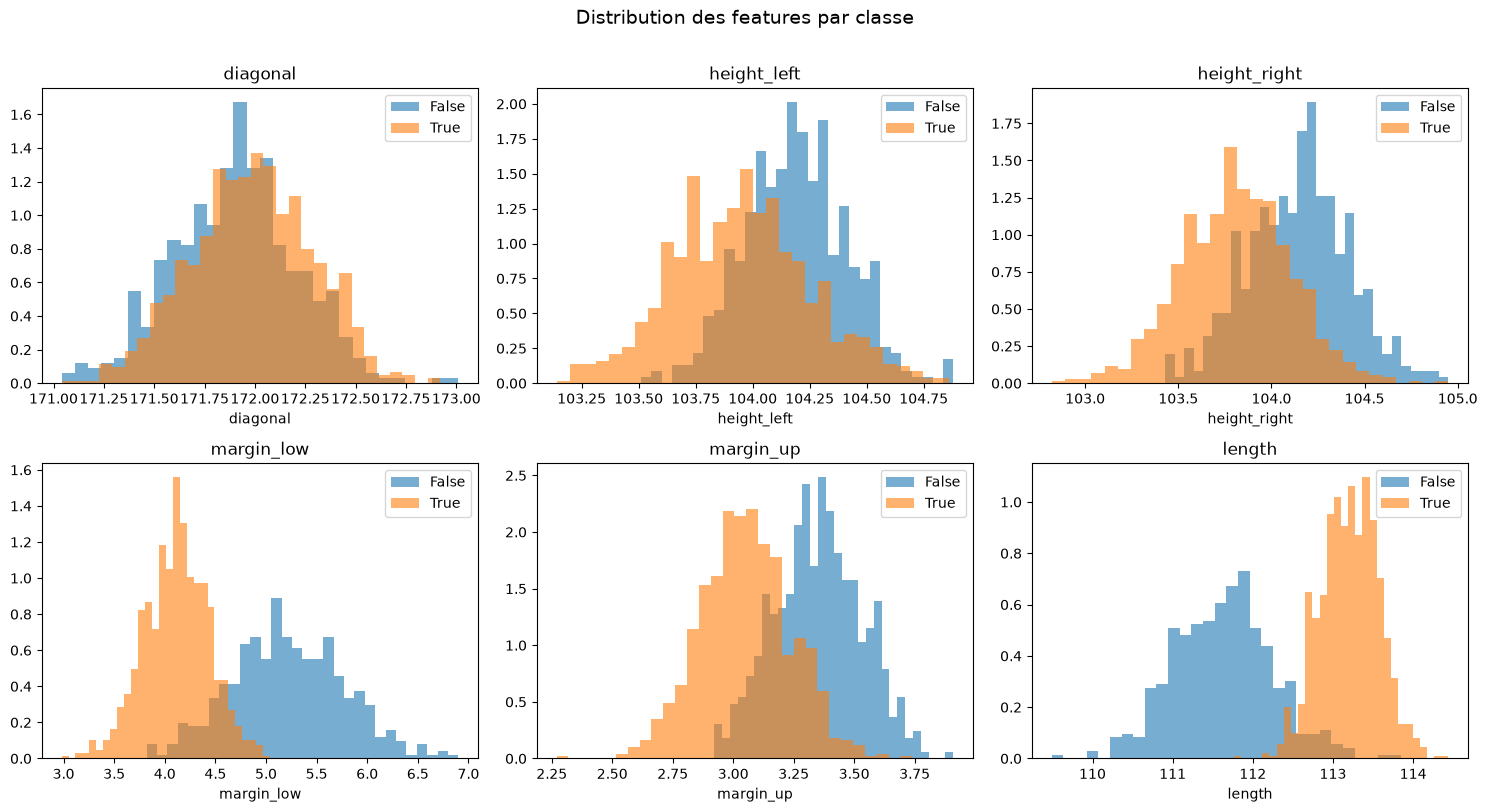

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, group in df.groupby('is_genuine'):
        axes[i].hist(group[col].dropna(), bins=30, alpha=0.6,
                     label=str(label), density=True)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_xlabel(col)

plt.suptitle('Distribution des features par classe', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}distributions.png', dpi=120, bbox_inches='tight')
plt.show()

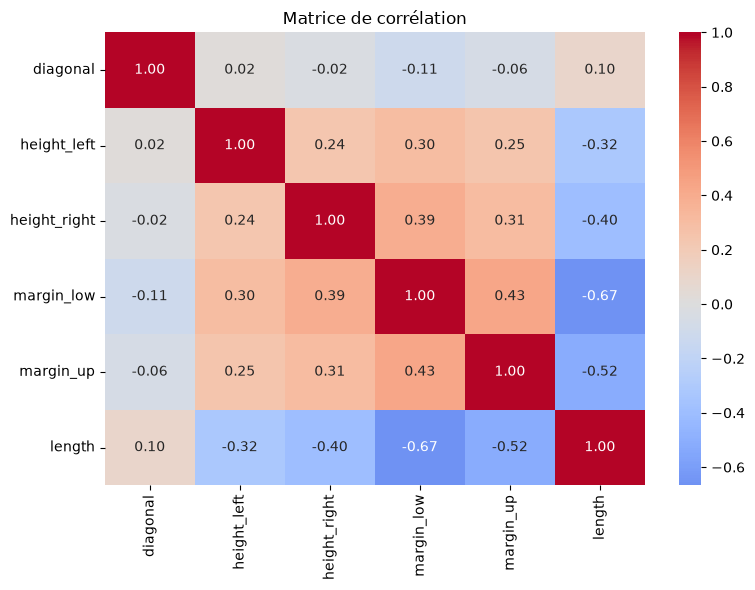

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}correlation.png', dpi=120, bbox_inches='tight')
plt.show()

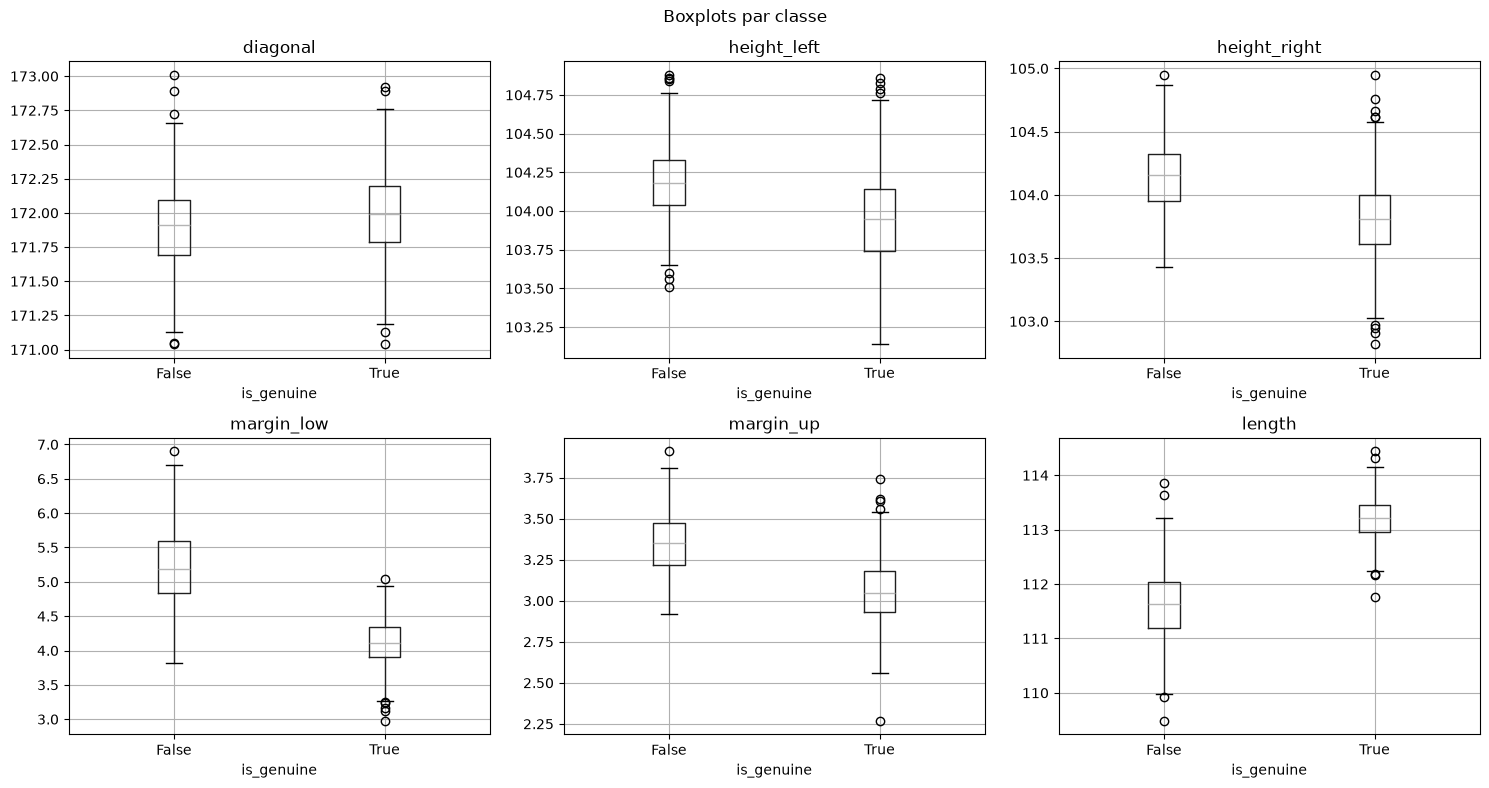

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='is_genuine', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('is_genuine')

plt.suptitle('Boxplots par classe')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [10]:
df2 = df.copy()
df2['is_genuine'] = df2['is_genuine'].map({True: 1, False: 0, 'True': 1, 'False': 0})
print('Encodage is_genuine :', df2['is_genuine'].value_counts().to_dict())

Encodage is_genuine : {1: 1000, 0: 500}


In [11]:
missing_idx = df2['margin_low'].isnull()
print(f'Lignes avec margin_low manquant : {missing_idx.sum()}')

imputer_features = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']

X_imp_train = df2.loc[~missing_idx, imputer_features]
y_imp_train = df2.loc[~missing_idx, 'margin_low']
X_imp_pred  = df2.loc[missing_idx, imputer_features]

lr_imp = LinearRegression()
lr_imp.fit(X_imp_train, y_imp_train)
df2.loc[missing_idx, 'margin_low'] = lr_imp.predict(X_imp_pred)

print(f'Valeurs manquantes restantes : {df2["margin_low"].isnull().sum()}')

joblib.dump(lr_imp, 'data_clean/imputer.pkl')
print('Imputer sauvegardé.')

Lignes avec margin_low manquant : 37
Valeurs manquantes restantes : 0
Imputer sauvegardé.


In [12]:
X = df2[features]
y = df2['is_genuine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print('Distribution train :', y_train.value_counts().to_dict())
print('Distribution test  :', y_test.value_counts().to_dict())

Train : 1125 | Test : 375
Distribution train : {1: 750, 0: 375}
Distribution test  : {1: 250, 0: 125}


In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

df_clean = df2.copy()
df_clean.to_csv('data_clean/billets_clean.csv', index=False)
print('Données nettoyées sauvegardées.')

Données nettoyées sauvegardées.


## 4. Modèle 1 — K-means

K-means est un algorithme non supervisé. La prédiction sur nouvelles données s'effectue par distance euclidienne aux centroïdes appris : le billet est affecté au centroïde le plus proche, et ce centroïde est aligné post-hoc avec la classe majoritaire observée en entraînement.

In [14]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_sc)

train_clusters = kmeans.labels_
cluster_to_class = {}
for cluster_id in [0, 1]:
    mask = train_clusters == cluster_id
    majority = y_train.values[mask].mean()
    cluster_to_class[cluster_id] = 1 if majority >= 0.5 else 0

print('Alignement cluster → classe :', cluster_to_class)

Alignement cluster → classe : {0: 0, 1: 1}


In [15]:
from numpy.linalg import norm

def predict_kmeans(X_scaled, kmeans_model, cluster_map):
    centers = kmeans_model.cluster_centers_
    distances = np.array([
        [norm(x - centers[0]), norm(x - centers[1])]
        for x in X_scaled
    ])
    nearest_cluster = distances.argmin(axis=1)
    return np.array([cluster_map[c] for c in nearest_cluster])

y_pred_km = predict_kmeans(X_test_sc, kmeans, cluster_to_class)

print('K-means — Rapport de classification :')
print(classification_report(y_test, y_pred_km, target_names=['Faux', 'Vrai']))

cm_km = confusion_matrix(y_test, y_pred_km)
print('Matrice de confusion :')
print(cm_km)

K-means — Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       125
        Vrai       0.99      0.99      0.99       250

    accuracy                           0.99       375
   macro avg       0.98      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375

Matrice de confusion :
[[123   2]
 [  3 247]]


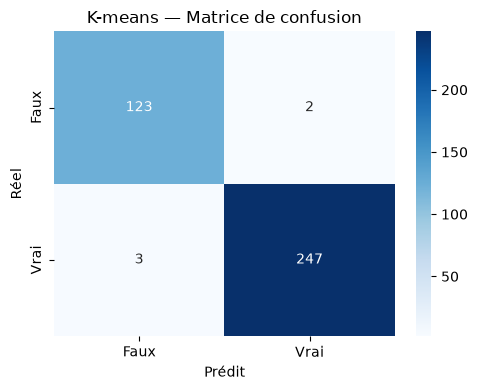

Recall(Faux) = 0.984


In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'], ax=ax)
ax.set_title('K-means — Matrice de confusion')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cm_kmeans.png', dpi=120, bbox_inches='tight')
plt.show()

recall_false_km = recall_score(y_test, y_pred_km, pos_label=0)
print(f'Recall(Faux) = {recall_false_km:.3f}')